![NWM](img/NWM.png)

# Watershed-Scale Analysis of ParFlow-CONUS Snow Outputs
Authors: Irene Garousi-Nejad (igarousi@cuahsi.org), Danielle Tijerina-Kreuzer (dtijerina@cuahsi.org)  
Last updated: February 2026

**Introduction**: This notebook uses the Princeton HydroData repository to gather [gridded ParFlow-CONUS1 SWE outputs](https://hf-hydrodata.readthedocs.io/en/latest/gridded_data/gridded_methods.html#get-gridded-data). See this [page more info on the PF-CONUS1 outputs](https://hf-hydrodata.readthedocs.io/en/latest/available_datasets.html#parflow-simulation-outputs).  
See the `hf_hydrodata` [Getting Started](https://hf-hydrodata.readthedocs.io/en/latest/getting_started.html) page for more information on the package and account.  
 
It uses Snotel data that is collected in the `01_data_collection.ipynb` notebook.  

### 1. Prepare the Python Environment

In [5]:
import os
import sys
import geopandas as gpd
import xarray as xr
import numpy as np
import pandas as pd
from dask.distributed import Client
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import hf_hydrodata as hf
import subsettools

from utils import nwm_utils
sys.path.append('../../../src/')
from cssi_evaluation.snow import utils

import holoviews as hv
import hvplot.xarray
import ipywidgets
hv.extension("bokeh")

%load_ext autoreload
%autoreload 2

### 1b. Register Pin and Access HydroData

To access the HydroData catalog you will need to sign up for a [HydroFrame account](https://hydrogen.princeton.edu/signup) (do this only once), [create a 4-digit PIN](https://hydrogen.princeton.edu/pin), and register your pin in order to have access to the HydroData datasets (you will do this in the next code cell below). To note, you PIN will expire after 7 days and will need to recreate it after that time. 

In [6]:
# You need to register on https://hydrogen.princeton.edu/pin 
# and run the following with your registered information
# before you can use the hydrodata utilities
hf.register_api_pin("dtt2@princeton.edu", "7837")

### 1c. Dask  

We'll use dask to parallelize our code. To manage parallel computation and visualize progress of long-running tasks, we initialize a Dask “cluster,” which defines how many workers are used and how much computing power each worker has. 

In this setup, we create a Dask client with `Client(n_workers=6, threads_per_worker=1, memory_limit='2GB')`, which launches a cluster with 6 workers. Each worker uses a single thread, typically mapped to one CPU core, allowing for efficient parallel processing across 6 cores. Each worker also has a memory limit of 2 GB, for a total of up to 12 GB across the cluster.

In [7]:
# use a try accept loop so we only instantiate the client
# if it doesn't already exist.
try:
    print('Dashboard link:', client.dashboard_link)
except:    
    # The client should be customized to your workstation resources.
    client = Client(n_workers=6, threads_per_worker=1, memory_limit='2GB') 
    print('Dashboard link:', client.dashboard_link)
print(client)

Dashboard link: http://127.0.0.1:8787/status
<Client: 'tcp://127.0.0.1:59579' processes=6 threads=6, memory=11.18 GiB>


## 2. Subset the modeled dataset to the watershed of interest

In this notebook, we take a deeper dive into analyzing the PF-CONUS1 snow model gridded outputs across the entire East-Taylor watershed. To do so, we'll use the same method from the point scale analysis (Notebook 02), using the HUC-08 ID to retrieve the SWE outputs for the East-Taylor over the period of interest. 

In [8]:
# Start and end times of a water year (note that this code currently works for one water year)
StartDate = '2003-10-01'
EndDate = '2005-09-30'

# Path to the watershed shapefile
watershed = './domain_data/East-Taylor_14020001.shp'
lat = np.load('./domain_data/East-Taylor_14020001_lat_2d.npy')
lon = np.load('./domain_data/East-Taylor_14020001_lon_2d.npy')

conus_latlon_gdf = gpd.read_file('./domain_data/East-Taylor_14020001_conus1_gridPoints_LatLon.shp')

# Read in SNOTEL observations from 01_HydroData_collection.ipynb 
obs_df = pd.read_csv(os.path.join('obs_outputs_PF', 'df_East-Taylor_14020001_SNOTEL.csv'))
obs_df = obs_df.set_index("date")
obs_df.index = pd.to_datetime(obs_df.index)

# Observations metadata 
metadata_df = pd.read_csv(os.path.join('obs_outputs_PF', 'df_East-Taylor_14020001_SNOTEL_metadata.csv'))

### 2a. Define the watershed of interest

We will continue to work with the same East-Taylor watershed from snow notebooks 01 & 02. The East-Taylor HUC-08 id is entered in the next cell.  

_Reminder:_ One of the simplest ways to gather data and model output from HydroData is by specifying a [Hydrologic Unit Code](https://www.usgs.gov/national-hydrography/watershed-boundary-dataset). Before we retrieve any hydrologic information, we need to indicate a HUC8 code and use it to gather snow water equivalent (SWE) observations from SNOTEL sites  

In [9]:
# ✏️ Specify HUC8 ID and Name for watershed of interest
huc_8_code = '14020001'  # East-Taylor HUC-8
print(f'HUC-8 ID: {huc_8_code}')

# Specify the name for the HUC-8 watershed (for labeling outputs)
huc_8_name = 'East-Taylor'
print(f'HUC-8 name: {huc_8_name}')

HUC-8 ID: 14020001
HUC-8 name: East-Taylor


In [10]:
### THIS CELL IS A PLACEHOLDER FOR USING THE plots.py FUNCTION, BUT IT'S NOT WORKING
# mask = np.load(f'./domain_data/domainMask_{huc_8_name}_conus1.npy')
# plots.plot_obs_locations(metadata_df,mask,'./')

Set up the daily and monthly time indices  
both for plotting and for monthly aggregation

In [11]:
# Set up a time index for the water year, since the np array returned doesn't have a time variable
day_times = pd.date_range(start=StartDate, end=EndDate, freq="D")
print(f"Number of days in the water year: {len(day_times)}")

month_times = pd.date_range("2003-10-01", periods=12, freq="MS")
print(f"Month start times: {month_times}")

Number of days in the water year: 731
Month start times: DatetimeIndex(['2003-10-01', '2003-11-01', '2003-12-01', '2004-01-01',
               '2004-02-01', '2004-03-01', '2004-04-01', '2004-05-01',
               '2004-06-01', '2004-07-01', '2004-08-01', '2004-09-01'],
              dtype='datetime64[ns]', freq='MS')


## 3. Retrieve ParFlow-CONUS2 gridded SWE output from HydroData  
Retrieve data from the HydroData using the HUC-08 ID for the East-Taylor watershed. First we create a multidimensional numpy array, which stores daily gridded SWE (with dimensions of `[#days, domain ny, domain nx]`). Then we use the day_times to create a DataArray of daily gridded PF-CONUS1 SWE.  

In [12]:
# retrieve gridded PF-CONUS1 SWE for the entire HUC8 watershed
grid_swe_options = {
        "dataset": "conus1_baseline_mod",
        "variable": "swe",
        "temporal_resolution": "daily",
        "start_time": StartDate, 
        "end_time": '2005-10-01', ### TO NOTE: the gridded function has exclusive end date, so this is hardcoded for now
        "huc_id": huc_8_code
    }
    
    # Get gridded data
grid_swe = hf.get_gridded_data(grid_swe_options)


# View the dimensions of the gridded data, which should be (days, ny, nx)
grid_swe.shape

(731, 49, 68)

Convert the model SWE from a raw NumPy array into an xarray.DataArray so the data has labeled dimensions and real dates attached to it. This makes it much easier to select by time, compute spatial averages, and aggregate to monthly or seasonal values in a clear and reproducible way.  
Also, assign the grid cell latitude and longitude from notebook 01 to the dataArray.

In [13]:
ny, nx = grid_swe.shape[1], grid_swe.shape[2]

y_index = np.arange(ny)
x_index = np.arange(nx)

# define water year for each day in the time index (water year starts October 1)
water_year = np.where(
    day_times.month >= 10,
    day_times.year + 1,
    day_times.year
)

grid_swe_da = xr.DataArray(
    grid_swe,
    dims=("time", "ny", "nx"),
    coords={
        "time": day_times,
        "water_year": ("time", water_year),
        "ny": y_index,
        "nx": x_index,
        "lat": (("ny", "nx"), lat),
        "lon": (("ny", "nx"), lon),
    },
)

Plot the spatial distribution of SWE across the East-Taylor HUC-08. Here, do this for one day:

In [14]:
grid_swe_map = grid_swe_da.sel(time="2004-04-01") #day to be plotted
grid_swe_map.hvplot.image(cmap="YlGnBu", colorbar=True, aspect="equal", title=f"{huc_8_name} Gridded SWE on 2004-04-01")

:Image   [nx,ny]   (value)

Now, plot the spatial distribution of SWE for every day of the selected time range. Go ahead and play around with the time slider below to see how SWE changes over time across the watershed.    

In [15]:
grid_swe_da.hvplot.image(
    x="nx",
    y="ny",
    groupby="time", #time slider
    widget_location="bottom",
    cmap="YlGnBu",
    colorbar=True,
    aspect="equal",
    frame_height=400
)


BokehModel(combine_events=True, render_bundle={'docs_json': {'fcea92c1-b3f7-4a38-a340-f05fd200426c': {'version…

##### _Interactive Plot Note_

This notebook uses `hvplot` + `holoviews` (Bokeh backend) for interactive time sliders and the interactive widgets **may not render properly in VS Code's notebook interface**.  

If the slider does not render:  
- Run this notebook in **JupyterLab or classic Jupyter Notebook** (in a terminal window, run `jupyter lab` and navigate to the notebook)
- Ensure `jupyter_bokeh` and `ipywidgets` are installed

## 4. Aggregate Hourly SWE Model Outputs

#### a. Daily Means  
Since PF-CONUS outputs at an hourly timestep, we compute daily mean simulated SWE for direct comparison to SNOTEL SWE observations. 

From the gridded swe `grid_swe_da` dataArray, compute the watershed daily mean and save as a Pandas dataframe:

In [16]:
# Compute the daily basin mean directly from the DataArray
mod_daily_mean_da = grid_swe_da.mean(dim=("ny", "nx"), skipna=True)

# Convert to a pandas DataFrame for comparison
mod_daily_mean_df = mod_daily_mean_da.to_dataframe(name="mod_basin_mean")

From the `obs_df` dataframe of the observed SWE at SNOTEL stations, create a new Pandas dataframe of the daily station mean:

In [18]:
# compute the daily mean across all observation sites for each day
obs_daily_mean_df = (obs_df.mean(axis=1).to_frame(name="obs_basin_mean"))

In [19]:
# Combine the daily mean observed and modeled data into a single dataframe for comparison (and plotting)
combined_daily_df = mod_daily_mean_df.join(obs_daily_mean_df, how="inner")
print(combined_daily_df.head())
type(combined_daily_df)

            water_year  mod_basin_mean  obs_basin_mean
time                                                  
2003-10-01        2004        0.000000             0.0
2003-10-02        2004        0.000000             0.0
2003-10-03        2004        0.000000             0.0
2003-10-04        2004        0.008404             0.0
2003-10-05        2004        0.000000             0.0


pandas.core.frame.DataFrame

In [20]:
nwm_utils.comparison_plots(combined_daily_df, 'obs_basin_mean', 'mod_basin_mean')

:Layout
   .Overlay.I  :Overlay
      .Curve.Observed_SWE :Curve   [date]   (obs_basin_mean)
      .Curve.Modeled_SWE  :Curve   [date]   (mod_basin_mean)
   .Overlay.II :Overlay
      .Scatter.I              :Scatter   [obs_basin_mean]   (mod_basin_mean,date)
      .Curve.A_1_colon_1_Line :Curve   [x]   (y)

#### b. Monthly Means

Use the gridded modeled SWE DataArray `grid_swe_da` from earlier in the notebook to compute daily means with the `.resample()` method to group the model output by a monthly frequency and compute the monthly mean. 

In [22]:
combined_monthly_df = combined_daily_df.resample("MS").mean()
combined_monthly_df.columns = ["water_year","mod_monthly_mean", "obs_monthly_mean"]
combined_monthly_df["water_year"] = (combined_monthly_df["water_year"].astype(int))
combined_monthly_df


,water_year,mod_monthly_mean,obs_monthly_mean
time,,,
2003-10-01,2004,0.059553,0.000000
2003-11-01,2004,36.086870,43.095333
2003-12-01,2004,78.614065,95.905484
2004-01-01,2004,147.503349,182.101613
2004-02-01,2004,189.490299,228.249655
2004-03-01,2004,197.776458,252.811935
2004-04-01,2004,166.556244,231.309333
2004-05-01,2004,92.969544,30.111290
2004-06-01,2004,18.603418,0.000000


In [23]:
grid_monthly_mean = grid_swe_da.resample(time="MS").mean(dim="time", skipna=True)

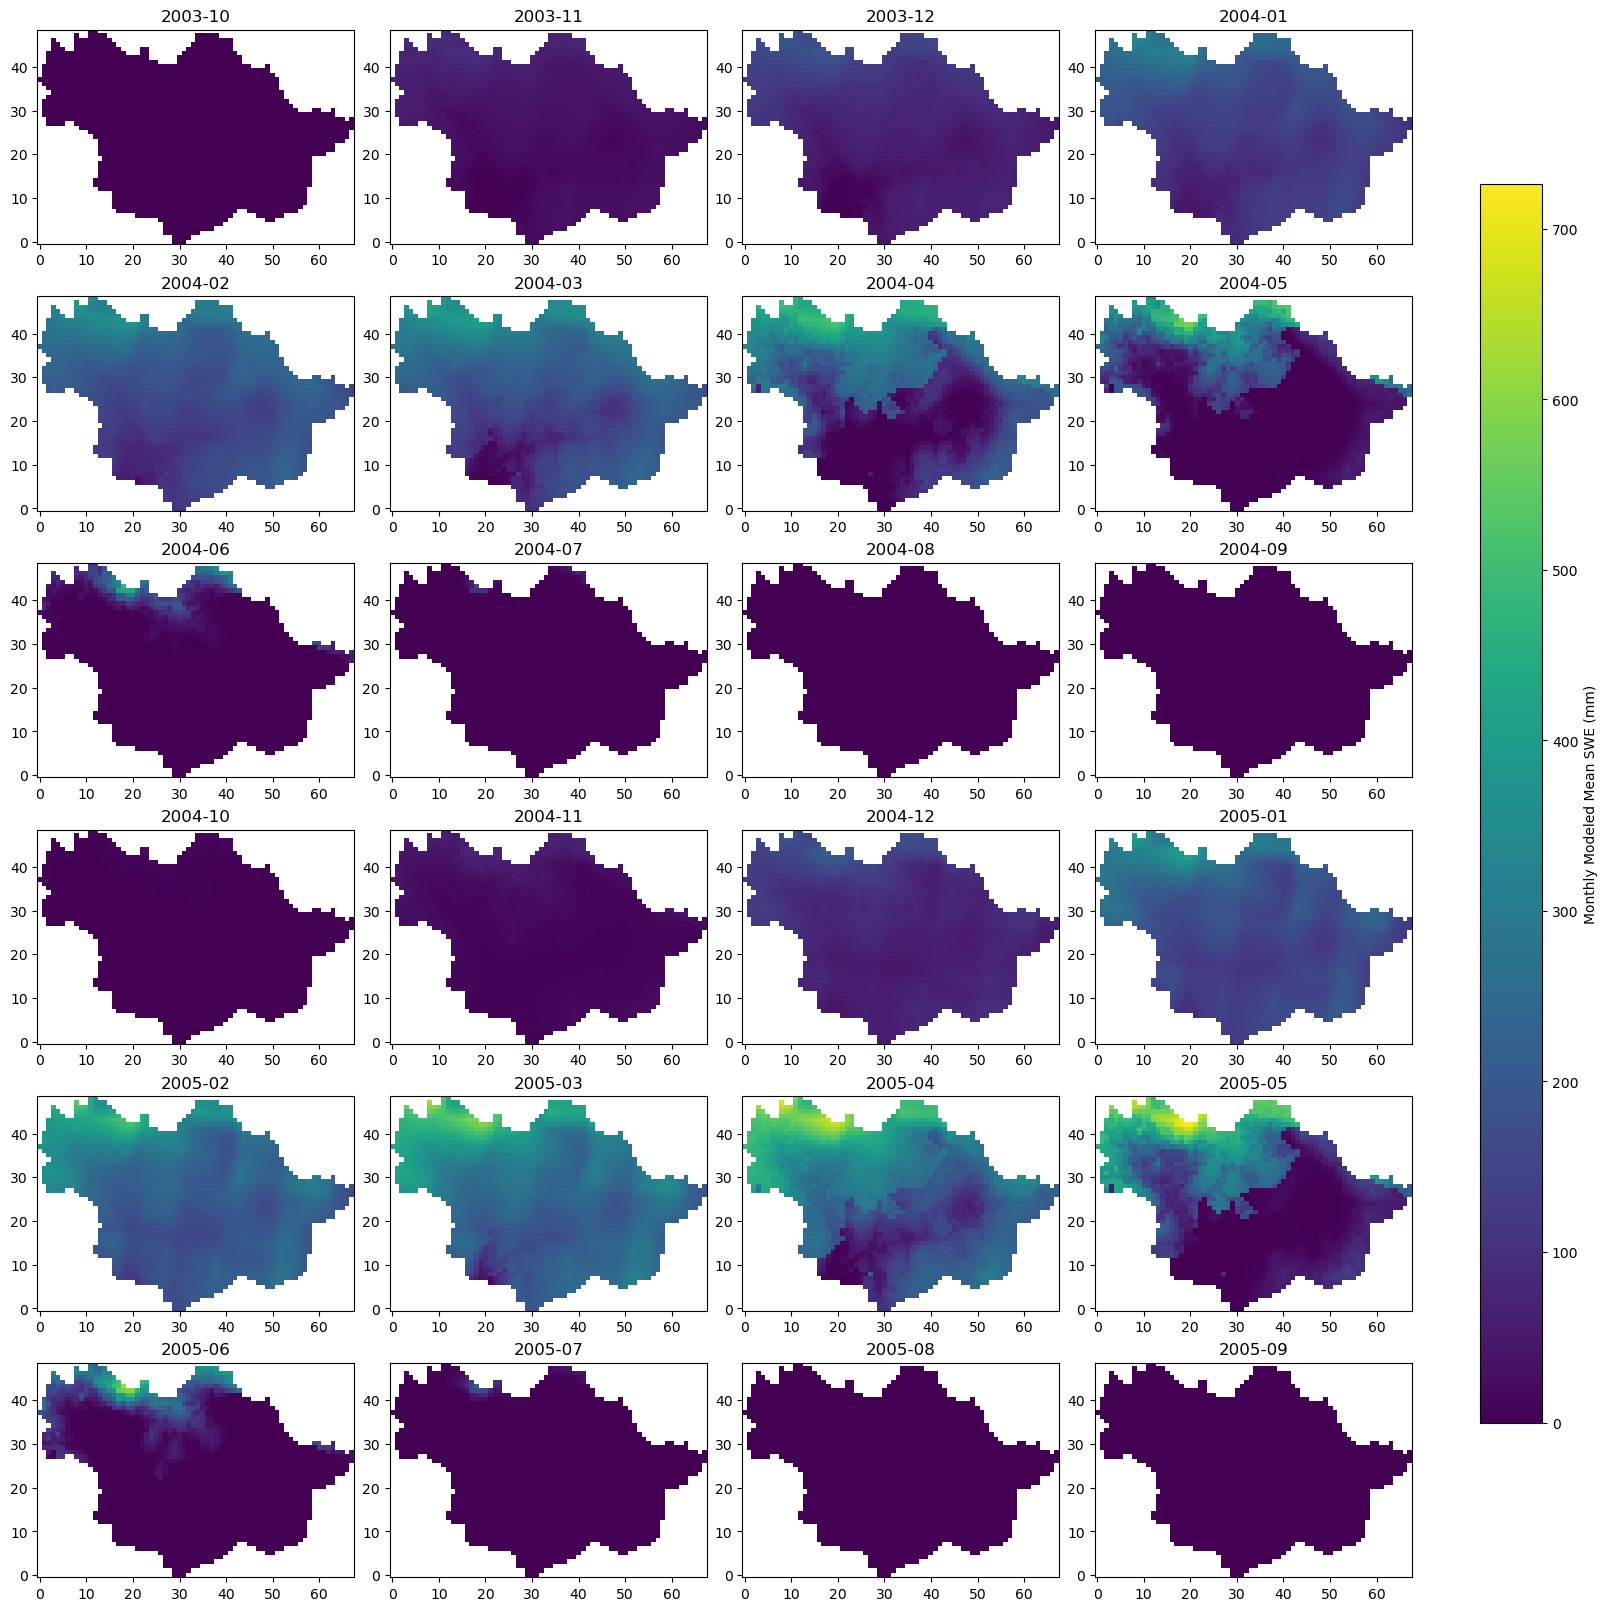

In [24]:
fig, axes = plt.subplots(6, 4, figsize=(16, 16), constrained_layout=True)

vmin = grid_monthly_mean.min().item()
vmax = grid_monthly_mean.max().item()

for i, ax in enumerate(axes.flat):
    grid_monthly_mean.isel(time=i).plot.imshow(ax=ax, vmin=vmin, vmax=vmax, add_colorbar=False)
    ax.set_title(str(grid_monthly_mean.time.values[i])[:7])
    ax.set_xlabel("")
    ax.set_ylabel("")

fig.colorbar(axes.flat[0].images[0], ax=axes, shrink=0.8, label="Monthly Modeled Mean SWE (mm)")


## 5. Watershed-Scale Spatial Snow Timing Analysis

Up to this point, we have examined basin‐average SWE, which tells us how much snow is stored across the watershed. However, snow accumulation and melt are highly spatial processes — peak snowpack and melt timing vary with elevation, aspect, and local climate conditions. To better understand how the model represents these spatial dynamics, we now compute timing-based metrics at each grid cell.

In the following section, we calculate three quantities for a selected water year, using the function `compute_snow_timing_grid()`:  
1. The date of peak SWE in a grid cell (maximum seasonal snow storage),
2. The date of full melt-out and a grid cell is snow-free (when snow effectively disappears), and
3. The duration of snow persistence after peak accumulation (melt period).

We define a grid cell as snow-free when the 5-day rolling average of SWE drops below 1 mm (e.g., the `threshold` and `smooth_window` within the function).

These maps provide a spatial view of snow storage and release across the watershed, showing patterns in accumulation and melt that are not visible in basin-averaged time series.

In [44]:
peak, melt, duration = utils.compute_snow_timing_grid(grid_swe_da, water_year=2004)

Water year 2004 starts on 2003-10-01 00:00:00


The function `compute_snow_timing_grid()` returns the **day of the water year** in which a grid cell reaches peak SWE and snow-free, as well as the melt duration between these dates.  
Next, we plot these quantities over the full watershed to get a better idea of spatial snow timing patterns.

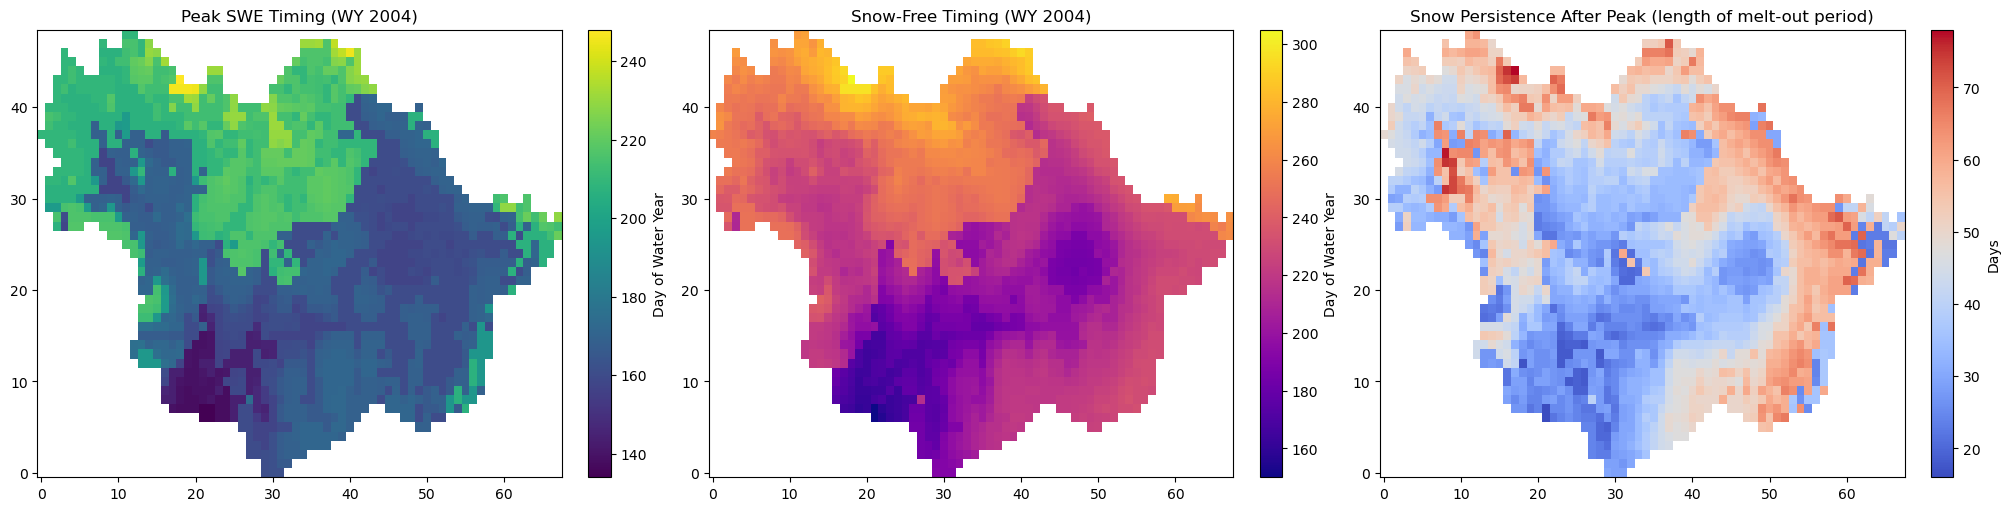

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(20,5), constrained_layout=True)

# Peak
im0 = peak.plot(ax=axes[0], cmap="viridis", add_colorbar=False)
axes[0].set_title("Peak SWE Timing (WY 2004)")
axes[0].set_xlabel("")
axes[0].set_ylabel("")
cbar0 = fig.colorbar(im0, ax=axes[0])
cbar0.set_label("Day of Water Year")

# Melt
im1 = melt.plot(ax=axes[1], cmap="plasma", add_colorbar=False)
axes[1].set_title("Snow-Free Timing (WY 2004)")
axes[1].set_xlabel("")
axes[1].set_ylabel("")
cbar1 = fig.colorbar(im1, ax=axes[1])
cbar1.set_label("Day of Water Year")

# Duration
im2 = duration.plot(ax=axes[2], cmap="coolwarm", add_colorbar=False)
axes[2].set_title("Snow Persistence After Peak (length of melt-out period)")
axes[2].set_xlabel("")
axes[2].set_ylabel("")
cbar2 = fig.colorbar(im2, ax=axes[2])
cbar2.set_label("Days")

1. This shows the day of the water year when snow accumulation reaches its maximum at each grid cell.  
2. This shows the day of the water year when snow effectively disappears at each grid cell.
3. This represents the number of days snow remains on the ground after reaching maximum accumulation.


<div style="color:black; background-color:#f5f5f5; padding:10px; border-left: 5px solid #007acc;">
  <h4>🧠 Reflect</h4>
  <p>
    What are potential causes of the spatial differences in snow timing? Why do you think the southwestern and central part of the watershed experiences shorter snow persistence duration than the edges of the watershed? We will explore this in the next section!
  </p>
</div>

#### b. Elevation Analysis  
_NOTE - DTK STILL TO DO 2/23:_  
2. **Elevation-binned SWE comparison - need elevation data**
This will be in the inputs  
OR we can grab the USGS elevation data  
Does this exist in HydroData?  
Snow line?  
Any cells that have elevation > some m has the potential to get snow  

In [27]:
# AMY IS WORKING ON THIS FUNCTION CALL IN HYDRODATA
elevation = hf.get_raw_file(dataset="conus1_domain", variable="elevation")
#elevation

TypeError: get_raw_file() missing 1 required positional argument: 'filepath'

<div style="color:black; background-color:#f5f5f5; padding:10px; border-left: 5px solid #007acc;">
  <h4>🧠 Reflect</h4>
  <p>
    What could be the potential sources of discrepancies between the spatially averaged SWE from the modeled and observed datasets within this catchment?  
How could you generate more reliable or informative statistics?  
How do you think the presence of SWE values equal to zero across large areas of the gridded dataset (as seen in the map above) — particularly when this pattern is consistent across the water year — might impact the spatially averaged SWE values?  
How could this influence your interpretation?
  </p>
</div>

<div style="color:black; background-color:#f5f5f5; padding:10px; border-left: 5px solid #007acc;">
  <h4>🧠 Reflect</h4>
  <p>
    In the plot above, you can see that in both accumulation and melt periods (e.g., Feb-Jun), snow was present in areas not covered by the existing observation points.  
How would having more observation points distributed across these snow-covered areas affect the basin-average SWE from observations, as calculated and plotted previously (`combined_df_mean`)?  
How could this change influence the bias, Nash-Sutcliffe Efficiency (NSE), and other statistical comparisons between modeled and observed SWE?  
And, how might improving the capture of spatial variability in SWE affect forecasts under future climate conditions?
  </p>
</div>